### Praval Singh Chawla
# FYS2130 Computational Essay: Kan man estimere biologisk kjønn basert på stemmens frekvensspekter? En anvendelse av Fourier-analyse på menneskelig tale


Menneskestemmen er et komplekst og unikt som først og fremst formidler ord og språk. Men stemmen vår bærer også informasjon om identitet og biologiske trekk, som for eksempel alder og kjønn. Vi mennesker kan ofte skille kjønn basert på stemmen alene. Å forstå hvilken informasjon som formidles gjennom stemmen, og hvordan man henter den ut, er viktig innenfor en rekke felt, blant annet teknologi, medisin og kunstig intelligens. I FYS2130 har denne problemstillingen en faglig forankring innenfor frekvens og harmoniske svingninger,  Fourier Transformasjon og digital filtrering.

I motsetning til komplekse maskinlæringsmetoder, bruker jeg relativt enkle tilnærminger basert på fysikk og signalbehandling. Utgangspunktet er selve lydsignalet fra menneskestemmen., som analyseres ved hjelp av Fouriertransformasjon for å finne frekvensinnholdet. Ved å finne den laveste dominerende frekvensen i signalet, anslår jeg en grunnfrekvens, som videre brukes til å estimere biologisk kjønn.

Dette prosjektet går ut på å gjøre taleopptak av mennesker som snakker, og deretter analysere disse opptakene ved hjelp av Fouriertransformasjon. Målet ved analysen er å kunne estimere grunnfrekvensen i taleopptaket, og se om den kan brukes til å estimere kjønn. Opptakene gjøres med både profesjonell mikrofon og mobiltelefon. Analysen gjennomføres med egenutviklet Python-program, hvor signalet hentes ut fra en wav-fil, filtreres og transformeres. Resultatene sammenlignes med kjente frekvensområder for manns- og kvinnestemmer.





## Lyd og grunnfrekvens

Lyd er kontinuerlige trykkbølger som beveger seg gjennom et medium, som oftest luft. Disse bølgene varierer med tid, og kan derfor representeres som en funksjon av tid. Når en mikrofon fanger opp trykkvariasjoner, konverteres de til elektriske signaler som deretter kan digitaliseres og analyseres videre. 

En sentral størrelse i bølgefysikk er frekvens (måles i Hz), som beskriver hvor ofte en bølge gjentar seg på et sekund. For stemmesignaler er spesielt én viktig, nemlig grunnfrekvensen ($f_0$). Dette er den laveste frekvenskomponenten i stemmen og bestemmer tonehøyden vi oppfatter. For stemmen er de hele multiplene av denne frekvensen ($2f_0$, $3f_0,$ osv...) også viktige, fordi summen av disse harmoniske komponentene gir stemmen sin unike klang. 

Menneskestemmen varier naturlig mellom individer, men det finnes også systematiske likheter basert på blant annet kjønn. Dette skyldes fysiologiske, forhold som for eksempel dimensjonene på stemmebåndet. For en generell streng som vibrerer er forholdet gitt ved følgende likning:

$$
f = \frac{1}{2L} \sqrt{\frac{T}{m/L}}
$$
hvor $L$ = strenglengde, $T$ = streng spenning og $m/L$ = masse per strenglengde (Dooley, 2013). Menneskets stemmebånd kan tilnærmes en vibrerende streng, og dermed er frekvensen omvendt proposjonal med strenglengde. Siden menn generelt har et lenger og tykkere stemmebånd enn kvinner, har de en lavere grunnfrekvens. Grunnfrekvensen i stemmen til en mann ligger vanligvis mellom 85 - 155 Hz, og for kvinner ligger den mellom 165 - 255 Hz (Watson, 2019). På grunn av denne intervallforskjellen, kan man bruke grunnfrekvensen som et estimat for biologisk kjønn. 

## Sampling og digitalisering av lyd

For å kunne hente ut frekvensinformasjon fra et digitalt lydsignal, må signalet først digitaliseres. Dette gjør man gjennom sampling, som vil si at man måler signalets amplitude ved faste tidspunkter. Resultatet blir diskrete verdier som representerer det orginale signalet, i form av en liste. Samplingfrekvensen ($f_s$) beskriver hvor ofte amplituden måles i løpet av et sekund. Et sentralt teorem innenfor signalbehandling, Nyquist-teoremet, sier at samplingfrekvensen må være minst dobbelt så høyt som den høyeste frekvensen i signalet ($f_s \geq 2 \cdot f_{max}$). Dette gir oss en grense som heter Nyquist-frekvensen ($f_N = \frac{1}{2}f_s$). Man gjør dette for å unngå fenomenet om aliasing. Fenomenet innebærer at høyere frekvenser feiltolkes som lavere frekvenser i det digitaliserte signalet. Dermed kan aliasing lede til feil konklusjon i analysen av et signal. Taleopptakene lagres i `wav`-format, som inneholder allerede samplede signaler. Samplingfrekvensen kan derfor hentes ut gjennom `scipy.io` sin `wavfile`-pakke. I tilfellet med menneskestemmer, må $f_s > 510$ Hz, siden den høyeste frekvensen er 255 Hz. 

## Fouriertransformasjon og frekvensdomene

Lydsignaler kan, som tidligere nevnt, representeres som en funksjon av tid. For å analysere frekvensene som finnes i et taleopptak, må signalet først transformeres fra tidsdomenet til frekvensdomenet. Dette gjøres ved hjelp av Fouriertransformasjon, som bryter ned signalet til en sum av sinus- og cosinuskomponenter med ulike frekvenser. Den kontinuerlige Fouriertransformasjonen av et signal $x(t)$ er definert av følgende likning:

$$
X(f) = \int_{-\infty}^{\infty} x(t)e^{-2\pi i f t} dt
$$
I praksis jobber vi med digitale signaler, som heller er diskrete. Derfor bruker vi den diskrete Fouriertransformasjonen, som gir et signal representert i frekvensdomenet som en liste. Denne listen har da $N$ diskrete frekvensverdier.

$$
X[k] = \sum_{n=0}^{N-1} x[n]e^{-2\pi i k n/N}
$$

Det er nettopp denne likningen som brukes i NumPy sin `np.fft.fft`. Resultatet til denne algoritmen er som forklart tidligere, en liste med komplekse tall der hver indeks representerer en frekvens og størrelsen $|X[k]|$ angir hvor sterkt frekvensen er representert i signalet. Frekvensspekteret er symmetrisk rundt null for reelle lydsignaler, og man kan derfor se bort fra negative frekvenser, siden de ikke inneholder ny informasjon. Derfor analyseres kun den positive delen av spekteret.

## Filtrering og forbedring av frekvensanalyse

For stemmeanalyse er målet å finne grunnfrekvensen, og i dette essayet estimeres grunnfrekvensen som frekvensen med størst amplitude. Men, den største amplituden i lydsignalet trenger ikke å være grunnfrekvensen, på grunn av støy og andre uønskede frekvenskomponenter. For å forbedre analysen og redusere disse uønskede frekvenense, brukes et digital båndpassfilter. 

Et båndpassfilter slipper kun gjennom et spesifikt frekvensintervall, og demper frekvenser utenfor dette intervallet. Siden vi skal finne grunnfrekvensen i en voksen menneskestemme, vet vi at $f_0$ ligger mellom 85 Hz - 255 Hz. Ved å filtrere bort frekvenser utenfor dette intervallet vil frekvensspekteret bli lettere å analysere. I tillegg vil grunnfrekvensen velges med større presisjon.

I programmet implementeres båndpassfilteret med et Butterworth-filter. Dette filteret kommer fra funksjonen `butter()` i `scipy.signal` pakken i Python. For å unngå faseforskyvning av signalet brukes også `filtfilt()`, som filtrerer signalet to ganger, frem og tilbake. Etter å ha filtrert signalet gjennomføres det Fouriertransformasjon, og grunnfrekvensen estimeres som den mest dominerende frekvensen. På denne måten blir analysen mer pålitelig, spesielt ved varierende opptakskvalitet. 

## Estimering av biologisk kjønn fra grunnfrekvens

Til slutt sammenlignes den estimerte grunnfrekvensen med frekvensintervallene for menn og kvinner, så estimeres biologisk kjønn basert på hvilket intervall som er nærmest grunnfrekvensen.


In [2]:
import numpy as np
import pandas as pd
import sounddevice as sd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from tabulate import tabulate
from scipy.signal import butter, filtfilt



class VoiceAnalyzer:

    def __init__(self, voice_file):
        """
        Lager en instanse for en gitt wav-fil. Henter ut samplingfrekvensen og 
        beregner Nyqusit-frekvensen.Sjekker om opptaket er mono eller stereo 
        opptak, velger kun én kanal dersom det er stereo. Beregner varigheten
        til opptaket basert på samplingfrekvensen og antall samples.
        
        Args:
            voice_file: Taleopptak i wav-format

        """
        self.voice_file = voice_file
        self.f_samp, self.data = wavfile.read\
                                (f"Voice_recordings/{self.voice_file}.wav")
        self.f_nyquist = self.f_samp * 0.5

        
        if len(self.data.shape) == 1:
            self.original_audio = self.data  
        else:
            self.original_audio = self.data[:, 0]
        
        self.samp_nums = len(self.original_audio)
        self.sound_time = self.samp_nums/ self.f_samp
        self.time = np.linspace(0, self.sound_time, self.samp_nums)


    def plot_sound(self):
        """
        Bruker varigheten til opptaket for å plotte lydsignalet i tidsdomenet.
        """

        plt.plot(self.time, self.original_audio)
        plt.xlabel("Tid (s)")
        plt.ylabel("Relativ amplitude")
        plt.title("Taleopptaket i tidsdomenet")
        plt.grid()
        plt.show()


    def fft(self, filter=False, plot_simple=False, plot_comparison=False):
        """
        Bruker Fouriertransformasjon til å vise taleopptaket i frekvensdomenet. 
        Ser kun på positive frekvenser. For å finne grunnfrekvensen med større 
        presisjon brukes et båndpassfilter, som filtrerer bort støy og uønskede 
        frekvenser.
        
        Args:
            filter: Velger om det enkle plottet skal vise det original eller 
            filtrert signal.

            plot_simple: Velger om et enkelt plott skal vises.

            plot_comparison: Velger om to plott som sammenligner filtrert og 
            originalt signal.

        """
        
        # Filtrert signal 
        low = 75 / self.f_nyquist
        high = 255 / self.f_nyquist
        b, a = butter(3, [low, high], btype='bandpass')
        self.x_filtered = filtfilt(b, a, self.original_audio.copy()) 

        # FFT original
        self.X_original_FFT = np.fft.fft(self.original_audio)
        self.N = len(self.X_original_FFT)
        self.freqs = np.fft.fftfreq(self.N, d=1/self.f_samp)
        self.pos_freqs = self.freqs[:self.N//2]
        self.pos_mag_original = np.abs(self.X_original_FFT[:self.N//2]) 
        self.dominant_original_index = np.argmax(self.pos_mag_original)
        
        # FFT filtrert
        self.X_filtered_FFT = np.fft.fft(self.x_filtered)
        self.pos_mag_filtered = np.abs(self.X_filtered_FFT[:self.N//2])
        self.dominant_filtered_index = np.argmax(self.pos_mag_filtered)
        
        if plot_simple:
            """
            Enkelt plot av frekvensdomenet, med eller uten filtrering
            
            """
            if filter:
                plt.plot(self.pos_freqs, self.pos_mag_filtered)
                plt.plot(self.pos_freqs[self.dominant_filtered_index],\
                self.pos_mag_filtered[self.dominant_filtered_index], 'ro',\
                label=f'f = {self.pos_freqs[self.dominant_filtered_index]:.2f} Hz')

            else:
                plt.plot(self.pos_freqs, self.pos_mag_original)
                plt.plot(self.pos_freqs[self.dominant_original_index],\
                self.pos_mag_original[self.dominant_original_index],'ro',\
                label=f'f = {self.pos_freqs[self.dominant_original_index]:.2f} Hz')
            
            plt.xlabel("Frekvens (Hz)")
            plt.ylabel("Amplitude")
            plt.title("Frekvensdomenet til taleopptaket")
            plt.xlim(0,500)
            plt.grid()
            plt.legend()
            plt.show()

        if plot_comparison:
            """
            Plot som sammenligner frekvensdomenet med og uten filter
            
            """
            plt.figure(figsize=(12, 5))

            plt.subplot(1, 2, 1)
            plt.plot(self.pos_freqs, self.pos_mag_original)
            plt.plot(self.pos_freqs[self.dominant_original_index],\
                self.pos_mag_original[self.dominant_original_index], 'ro',\
                label=f'f = {self.pos_freqs[self.dominant_original_index]:.2f} Hz')
            
            plt.xlabel("Frekvens (Hz)")
            plt.ylabel("Relativ amplitude")
            plt.title("Ufiltrert frekvensdomenet")
            plt.xlim(0,4000)
            plt.grid()
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(self.pos_freqs, self.pos_mag_filtered)
            plt.plot(self.pos_freqs[self.dominant_filtered_index],\
                self.pos_mag_filtered[self.dominant_filtered_index], 'ro',\
                label=f'f = {self.pos_freqs[self.dominant_filtered_index]:.2f} Hz')
            plt.xlabel("Frekvens (Hz)")
            plt.ylabel("Relativ amplitude")
            plt.title("Filtrert frekvensdomenet")
            plt.xlim(0,4000)
            plt.legend()
            plt.grid()

            plt.tight_layout()

            plt.show()



    def voice_gender(self):
        """
        Estimerer biologisk kjønn basert på grunnfrekvens og relevant 
        frekvensintervaller. Den kritiske frekvensen er mellom øverste grense 
        for menn og nederste grense forkvinner. Dersom grunnfrekvensen er 
        over/under denne frekvensen, blir estimatet feminin/maskulin.

        """

        male_upper_freq = 155
        female_lower_freq = 165
        crit_freq = (male_upper_freq + female_lower_freq) / 2       


        self.dominant_index = np.argmax(self.pos_mag_filtered) 
        self.dominant_freq = self.pos_freqs[self.dominant_index] 

        if self.dominant_freq > crit_freq:
            return f"Feminin"
        else:
            return f"Maskulin"
        

    def play_audio(self, filtered=False):
        """
        Funksjon som kan spille av lydsignalet.

        """
        
        if filtered:
            audio = 0.01 * self.x_filtered

        else:
            audio = self.original_audio
        
        sd.play(audio, self.f_samp)
        sd.wait()  # Venter til lyden er ferdigspilt


Samplingfrekvensen i wav filen er 48000 Hz


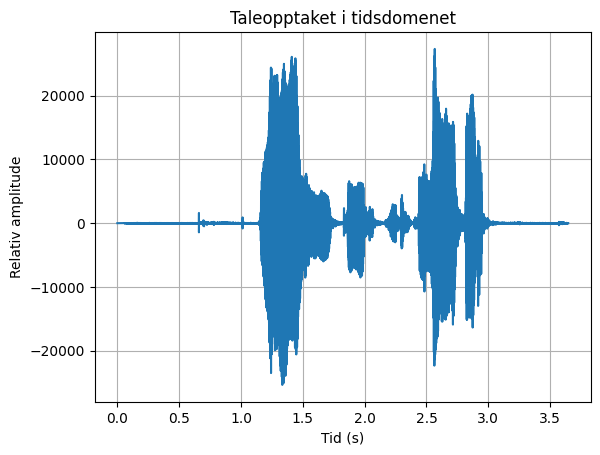

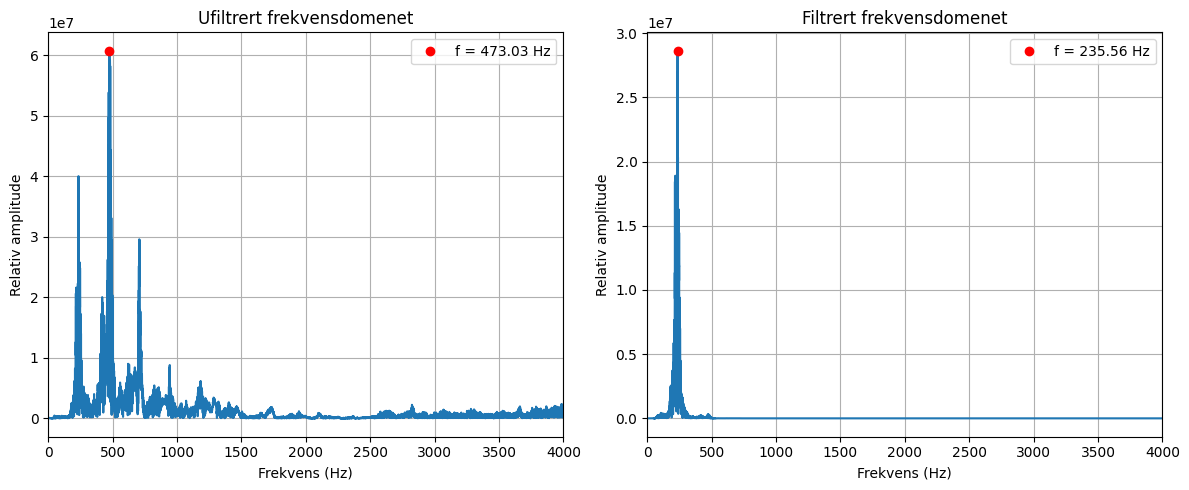

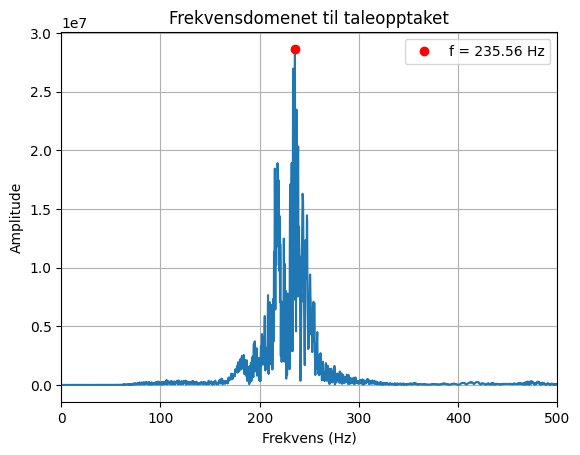

Det estimerte kjønnet i dette taleopptaket er Feminin


In [3]:
# Kjøreeksempel

voice1 = "Alka"             # Profesjonell mikrofon
voice2 = "Praval"           # Profesjonell mikrofon
voice3 = "Marlene"          # Mobiltelefon
voice4 = "Marlene_mork"     # Mobiltelefon
voice5 = "Merete"           # Mobiltelefon
voice6 = "Tom_lys"          # Mobiltelefon
voice7 = "Tom_mork"         # Mobiltelefon
voice8 = "Tomas"            # Mobiltelefon


# Bruk av klassen

eksempel = VoiceAnalyzer(voice4)                                        
print(f"Samplingfrekvensen i wav filen er {eksempel.f_samp} Hz")        
eksempel.plot_sound()                                                   
eksempel.fft(filter=True, plot_simple=False, plot_comparison=True)      
eksempel.fft(filter=True, plot_simple=True, plot_comparison=False)      
print(f"Det estimerte kjønnet i dette taleopptaket er {eksempel.voice_gender()}")

# Initierer et objekt med Marlene_mørk.wav
# Printer samplingfrekvensen til opptaket
# Plotter opptaket i tidsdomenet
# Viser en sammenligning av frekvendsdomenet med og uten filtrering
# Viser frekvensdomenet med relevante frekvenser for analysen

In [4]:
voices = [voice1, voice2, voice3, voice4, voice5, voice6, voice7, voice8]

Gender = ["Feminin", "Maskulin", "Feminin", "Feminin", "Feminin", "Maskulin",\
           "Maskulin", "Maskulin"]
Estimate = []
Check = []

for i in range(len(voices)):
    
    instance = VoiceAnalyzer(voices[i])
    instance.fft(filter=True, plot_simple=False, plot_comparison=False)
    Estimate.append(instance.voice_gender())
    Check.append(instance.voice_gender() == Gender[i])

# Tabell for resultater (KI-generert)

df = pd.DataFrame({
    "Navn": voices,
    "Estimert kjønn": Estimate,
    "Faktisk kjønn": Gender,
    "Riktig?": Check
})

print(tabulate(df, headers='keys', tablefmt='pretty'))

+---+--------------+----------------+---------------+---------+
|   |     Navn     | Estimert kjønn | Faktisk kjønn | Riktig? |
+---+--------------+----------------+---------------+---------+
| 0 |     Alka     |    Feminin     |    Feminin    |  True   |
| 1 |    Praval    |    Maskulin    |   Maskulin    |  True   |
| 2 |   Marlene    |    Feminin     |    Feminin    |  True   |
| 3 | Marlene_mork |    Feminin     |    Feminin    |  True   |
| 4 |    Merete    |    Feminin     |    Feminin    |  True   |
| 5 |   Tom_lys    |    Maskulin    |   Maskulin    |  True   |
| 6 |   Tom_mork   |    Maskulin    |   Maskulin    |  True   |
| 7 |    Tomas     |    Maskulin    |   Maskulin    |  True   |
+---+--------------+----------------+---------------+---------+


## Resultater

I "Taleopptak i tidsdomenet" plottet ser man hvordan lydintensiteten endrer seg over tid, og hvor lenge opptaket varer. 

Plottene "Ufiltrert frekvensdomenet" og "Filtrert frekvensdomenet" viser tydelig hvordan den digitale filtreringen hjelper programmet med å anslå en mer presis grunnfrekvens. Før filtrering ser man at grunnfrekvensen er 473.03 Hz, noe som ikke samsvarer med de kjente frekvensområdene. Etter filtrering er frekvensen 235.56 Hz, noe som samsvarer med de kjente frekvensområdene, i tillegg til at det samsvarer med det virkelige kjønnet. 

Man kan se frekvensspekteret tydligere i "Frekvensdomenet til taleopptaket" plottet. Her ser man også at de andre dominerende frekvensene ligger tett rundt den anslåtte grunnfrekvensen.

Tabellen over viser resultatet av programmet for åtte forskjellige taleopptak. Fra siste kolonne ser man at programmet estimerte riktig kjønn for alle opptakene.

## Diskusjon

For en enklere tilnærming valgte jeg å kun se på grunnfrekvens for å estimere kjønn. Hvis man hadde analysert frekvensspekteret grundigere og sett på flere parametere ville man fått bedre presisjon og nøyaktighet. Man kunne da ha brukt programmet på en videre målgruppe enn bare voksne menn og kvinner. I tillegg kunne man kanskje ha estimert alder med disse forbedringene også. 

De to første lydopptakene er gjort med en mer profesjonell mikrofon i rolige omgivelser, og opptaket er tatt i `wav`-format. De resterende opptakene er gjort på iPhone i en mer sosial omgivelse, noe som kan gi støy i opptaket. I tillegg er de tatt opp i `m4a`-format, som da måtte konverteres til `wav`. Denne prosessen kan for eksempel ha påvirket signalet i form av samplingfrekvensen. 

Jeg valgte å bruke opptaket "Marlene_mørk" som eksempel for plottene, da filtreringen tydelig kommer frem. Dette er et av opptakene som er gjort på iPhone i en sosial omgivelse, noe som gir mening med filtreringen. I tillegg var det interessant å se at en "formørkning" av stemmen ikke påvirket grunnfrekvensen i stor grad. Ved å kjøre programmet for opptaket "Marlene", hvor samme personen snakker med "vanlig" stemme, anslår programmet en grunnfrekvens på 235.03 Hz. 

Som svar på problemstillingen så kan programmet estimere kjønnet til voksne menn og kvinner. Dersom man utvider analysemetoden vil man mest sannsynlig kunne gjøre enda flere og bedre estimeringer. 


## Deklarering av bruk av KI

I dette vitenskapelige arbeidet har generativ kunstig intelligens (KI) blitt benyttet. Alle data og personopplysninger er blitt behandlet i henhold til Universitetet i Oslos reglement og jeg som forfatter av dokumentet tar fullt ansvar for dets innhold, påstander og referanser. En oversikt over bruken av generativ KI er gitt under.

- Feilsøking av kode, for å kontrollere dimensjonen til data i `___init___` funksjonen i `VoiceAnalyzer`, (GPT-4o).
- Lage kode for datatabell med `pandas`, (GPT-4o). 


## Kilder

- cloudconvert. (Årstall, dato). M4A to WAV Converter. cloudconvert. URL: https://cloudconvert.com/m4a-to-wav
- Dooley, P. (2013, 21. mars) *About String Calculator*. WireStrungharp. URL: https://www.wirestrungharp.com/material/strings/about_string_calculator/
- Lofft, A. (ukjent dato). *Audio Oddities: Frequency Ranges of Male, Female and Children's Voices*. axiom. URL: https://www.axiomaudio.com/blog/audio-oddities-frequency-ranges-of-male-female-and-childrens-voices
- Watson, S. (2019). *The Unheard Female Voice*. ASHAWIRE. URL: https://leader.pubs.asha.org/doi/10.1044/leader.FTR1.24022019.44#:~:text=In%20general%2C%20women%20speak%20at,cords%20to%20elongate%20and%20thicken
